# Queue Lengths and Traffic Heatmaps

This notebook shows how to use the `simulation` module together with the
`analytics` helpers to inspect queue dynamics and traffic density.

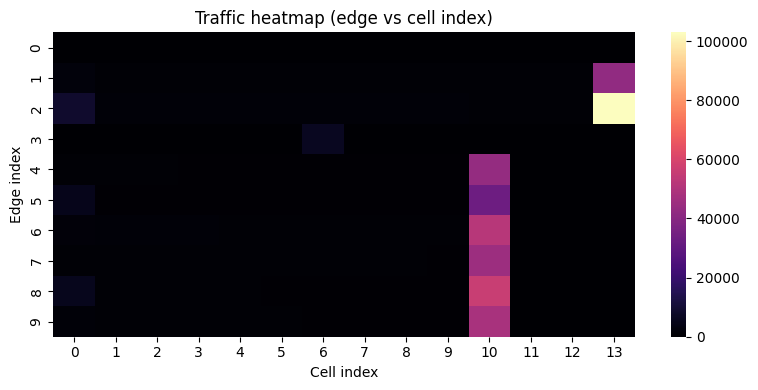

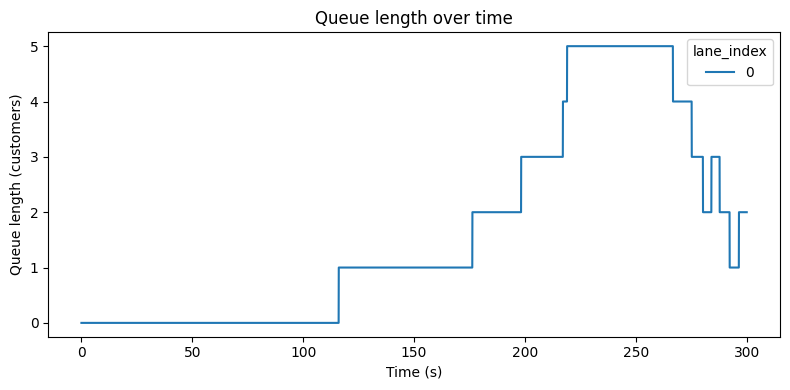

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

import analytics
import simulation

# Run a short simulation and keep the Simulator object
result = analytics.run_simulation(
    store_path="store.yaml",
    duration_seconds=300.0,
    spawn_interval=5.0,
    mission_probability=1.0,
    seed=1234,
)
sim = result.simulator

# Traffic heatmap (edge/cell space)
cell_counts = sim.get_cell_heatmap()
heatmap_df = analytics.cell_heatmap_to_frame(cell_counts)

pivot = heatmap_df.pivot_table(
    index="edge_index", columns="cell_index", values="visits", fill_value=0
)
plt.figure(figsize=(8, 4))
sns.heatmap(pivot, cmap="magma")
plt.title("Traffic heatmap (edge vs cell index)")
plt.xlabel("Cell index")
plt.ylabel("Edge index")
plt.tight_layout()
plt.show()

# Queue metrics
times = sim.get_queue_sample_times()
lengths = sim.get_queue_lengths_history()
queue_df = analytics.queue_metrics_to_frame(times, lengths)

plt.figure(figsize=(8, 4))
sns.lineplot(data=queue_df, x="time_s", y="queue_length", hue="lane_index")
plt.title("Queue length over time")
plt.xlabel("Time (s)")
plt.ylabel("Queue length (customers)")
plt.tight_layout()
plt.show()